In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM


In [2]:
cube="/global/cfs/cdirs/desi/cosmosim/SecondGenMocks/AbacusSummit/CubicBox/BGS/v0.1/z0.200/AbacusSummit_base_c000_ph000/BGS_box_ph000.fits"
cube=Table.read(cube)

cube.info("stats")

<Table length=232248642>
   name       mean        std         min         max    
--------- ----------- ----------- ----------- -----------
R_MAG_ABS    -19.3185    0.920158     -23.777         -18
 G_R_REST    0.611554    0.258145   -0.412737     1.71584
HALO_MASS     2057.82     9599.53     12.6545      295815
      cen    0.847167    0.359826           0           1
        x     999.934     577.215 3.23931e-05        2000
        y     1000.32     577.603           0        2000
        z     998.971     576.732           0        2000
       vx  -0.0871948      378.77    -6566.72     6162.29
       vy   0.0435059      377.95    -6635.32     6816.61
       vz   0.0108523     382.653    -6459.76     6721.44
 FILE_NUM     16.5085     9.81362           0          33
  HALO_ID 8.50016e+16 4.90921e+16     2.5e+07 1.70017e+17


In [38]:
mock="/global/cfs/cdirs/desi/cosmosim/SecondGenMocks/AbacusSummit/CutSky/BGS/v0.1/z0.200/cutsky_BGS_z0.200_AbacusSummit_base_c000_ph000.fits"
mockfull=Table.read(mock)
mask = (np.random.rand(mockfull['RA'].size)<1.0) # 1% sample
mock=mockfull[mask].copy()
mock.info("stats")

<Table length=63897781>
   name        mean        std         min         max    
---------- ----------- ----------- ----------- -----------
 R_MAG_APP     19.2843    0.864079      8.3046        20.2
 R_MAG_ABS    -20.0706      1.2135    -27.4689    -10.1176
  G_R_REST    0.688292    0.244958   -0.962171      1.8486
   G_R_OBS     1.02213    0.405673   -0.942033     2.56191
       DEC     0.10975     39.2131    -89.9936      89.984
 HALO_MASS     2148.07     9354.16     1.81842      295815
       CEN    0.867892    0.338608           0           1
       RES    0.980984    0.136583           0           1
        RA     180.131     103.971           0         360
   Z_COSMO    0.250433    0.114661 0.000923433    0.803471
         Z    0.250552     0.11456 0.000733239    0.799884
  FILE_NUM     16.5038     11.9651           0          33
HALO_INDEX  4.6147e+06 3.61185e+06           0 1.15911e+07
 BOX_INDEX 2.61203e+06 2.18084e+06          -1 6.94162e+06
     IN_Y1    0.236425    0.4248

In [42]:
# Convert to cubic x y z
cosmo = FlatLambdaCDM(H0=100, Om0=0.313, Tcmb0=2.725)   #Standard Planck Cosmology in Mpc/h units
mock['radial_dist']=cosmo.comoving_distance(mock['Z_COSMO']).value  
mock['x']=mock['radial_dist']*np.cos(np.deg2rad(mock['DEC']))*np.cos(np.deg2rad(mock['RA']))
mock['y']=mock['radial_dist']*np.cos(np.deg2rad(mock['DEC']))*np.sin(np.deg2rad(mock['RA']))
mock['z']=mock['radial_dist']*np.sin(np.deg2rad(mock['DEC']))
mock['x']=mock['x'] % 2000
mock['y']=mock['y'] % 2000
mock['z']=mock['z'] % 2000

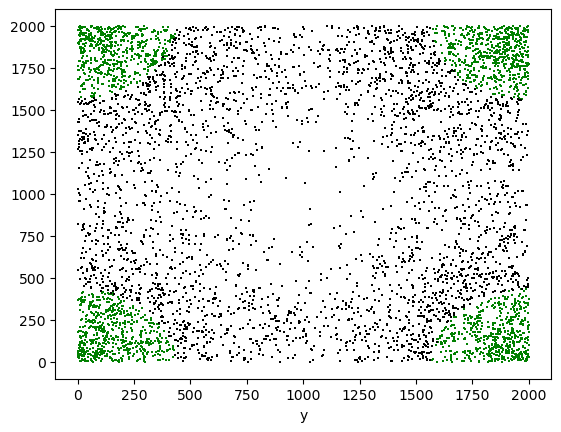

In [23]:
#

mask= (mock['BOX_INDEX']==-1) & (np.absolute(mock['z'])<10.0)
plt.scatter(mock['x'][mask],mock['y'][mask],marker=',',  lw=0, s=1.0, alpha=1.0, color='green')
mask= (mock['BOX_INDEX']!=-1) & (np.absolute(mock['z'])<10.0)
plt.scatter(mock['x'][mask],mock['y'][mask],marker=',',  lw=0, s=1.0, alpha=1.0, color='black')
plt.xlabel('x')
plt.xlabel('y')
plt.show()

In [24]:
print(mock['BOX_INDEX'][mask])



BOX_INDEX
---------
  5368655
  5936341
    83722
   148836
   191022
   196157
   207261
   430077
   433434
   540766
      ...
  5720507
  6060846
  6124543
  6319173
  6471571
  6471587
  6657168
  6906440
  6914902
  3287834
  5818147
Length = 3446 rows


In [25]:
mask = (mock['BOX_INDEX']==755111)
print(mock['x'][mask],mock['y'][mask],mock['z'][mask])
print(cube['x'][755111],cube['y'][755111],cube['z'][755111])

 x 
---  y 
---  z 
---
13.591736 956.3114 1996.8464


In [26]:
mock.info("stats")

<Table length=638426>
    name        mean        std         min         max    
----------- ----------- ----------- ----------- -----------
  R_MAG_APP     19.2842    0.864695     10.3242        20.2
  R_MAG_ABS    -20.0706     1.21367      -27.44    -10.9676
   G_R_REST    0.688398    0.244962    -0.54607     1.67033
    G_R_OBS     1.02228    0.405801   -0.533316     2.42026
        DEC    0.227258     39.2009    -89.9173     89.8228
  HALO_MASS     2141.15     9337.19     1.87944      295815
        CEN    0.868008    0.338482           0           1
        RES    0.980834    0.137108           0           1
         RA      180.23     103.985 0.000157858         360
    Z_COSMO    0.250473    0.114745  0.00155137    0.800053
          Z    0.250588    0.114648  0.00218449    0.799884
   FILE_NUM      16.495      11.968           0          33
 HALO_INDEX 4.61365e+06 3.61132e+06           0 1.15908e+07
  BOX_INDEX 2.61245e+06 2.18136e+06          -1 6.94152e+06
      IN_Y1    0.2

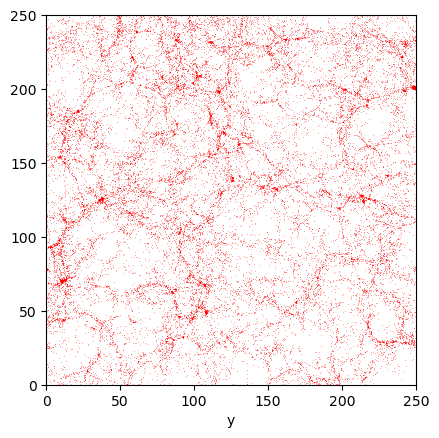

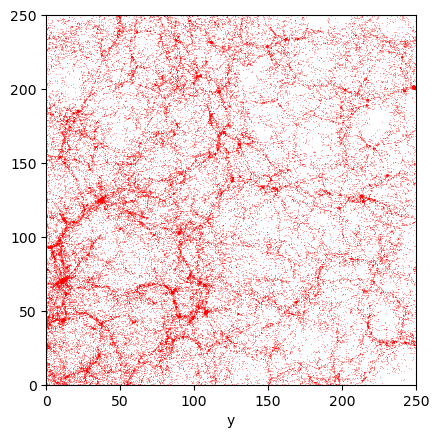

In [43]:
mask = (np.absolute(cube['z']-00.0)<20.0)

plt.gca().set_aspect('equal', adjustable='box')
plt.scatter(cube['x'][mask],cube['y'][mask],marker='.',  lw=0, s=0.5, alpha=1.0, color='red')
plt.xlabel('x')
plt.xlabel('y')
plt.xlim([0,250.])
plt.ylim([0,250.])
plt.show()

mask = (np.absolute(mock['z']-00.0)<20.0)
plt.gca().set_aspect('equal', adjustable='box')
plt.scatter(mock['x'][mask],mock['y'][mask],marker='.',  lw=0, s=0.5, alpha=1.0, color='red')
plt.xlabel('x')
plt.xlabel('y')
plt.xlim([0,250.])
plt.ylim([0,250.])
plt.show()

In [ ]:
mask= (mock['BOX_INDEX']==-1)
sample=mock[mask].copy()
sample.info('stats')

In [ ]:
halo_file = "/global/cfs/cdirs/desi/public/cosmosim/AbacusSummit/AbacusSummit_base_c000_ph000/halos/z0.200/halo_info/halo_info_000.asdf"
cat = CompaSOHaloCatalog(
halo_file,
# fields=["id", "x_com", "N"],
subsamples=False,
convert_units=True, # gives x_com in box units like [-1000, 1000] Mpc/h
verbose=False,
)
print("n_halos:", len(cat.halos))
print("columns:", cat.halos.colnames)
print("x_com min/max:", cat.halos["x_com"].min(), cat.halos["x_com"].max())


In [ ]:
r=mock['Z_COSMO']
zz=r*np.sin(np.deg2rad(mock['DEC']))
xx=r*np.cos(np.deg2rad(mock['DEC']))*np.cos(np.deg2rad(mock['RA']))
yy=r*np.cos(np.deg2rad(mock['DEC']))*np.sin(np.deg2rad(mock['RA']))

In [ ]:
mask= ( np.abs(zz)<0.1 ) & (mock['BOX_INDEX']!=-1)
plt.scatter(xx[mask],yy[mask],marker=',',  lw=0, s=1.0, alpha=0.005, color='black')
mask= (mock['BOX_INDEX']==-1) &  ( np.abs(zz)<0.1 )
plt.scatter(xx[mask],yy[mask],marker=',',  lw=0, s=1.0, alpha=0.01, color='red')
plt.show()

In [ ]:
#
mask= (mock['BOX_INDEX']!=-1) & (np.abs(mock['Z_COSMO']-0.3)<0.001)
plt.scatter(mock['RA'][mask],mock['DEC'][mask],marker=',',  lw=0, s=1.0, alpha=0.01, color='black')
plt.show()
mask= (mock['BOX_INDEX']==-1)  & (np.abs(mock['Z_COSMO']-0.1)<0.001)
plt.scatter(mock['RA'][mask],mock['DEC'][mask],marker=',',  lw=0, s=1.0, alpha=0.01, color='red')
plt.show()

In [ ]:
sim=Table.read("/global/cfs/cdirs/desi/public/cosmosim/AbacusSummit/AbacusSummit_base_c000_ph000/halos/z0.200/halo_info/halo_info_000.asdf")
sim.info('stats')

In [ ]:
import matplotlib.pyplot as plt
